# Exploration de la Base de Données

Guide complet pour comprendre le dataset Ames Housing (données brutes).

**Note** : Pour l'analyse des données traitées, voir `house_price_01_analyse.ipynb`.


In [1]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Bibliothèques importées avec succès")


Bibliothèques importées avec succès


## 1. Chargement et Aperçu Initial


In [2]:
# Chargement des données
train_df = pd.read_csv('../data/raw/train.csv')
test_df = pd.read_csv('../data/raw/test.csv')

print("=" * 60)
print("INFORMATIONS GÉNÉRALES SUR LE DATASET")
print("=" * 60)
print(f"\nDonnees d'entrainement:")
print(f"   - Nombre de lignes: {train_df.shape[0]:,}")
print(f"   - Nombre de colonnes: {train_df.shape[1]}")
print(f"   - Taille memoire: {train_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\nDonnees de test:")
print(f"   - Nombre de lignes: {test_df.shape[0]:,}")
print(f"   - Nombre de colonnes: {test_df.shape[1]}")
print(f"   - Taille memoire: {test_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\nDifference:")
print(f"   - Colonnes dans train mais pas dans test: {set(train_df.columns) - set(test_df.columns)}")
print(f"   - Colonnes dans test mais pas dans train: {set(test_df.columns) - set(train_df.columns)}")

# Vérification de la variable cible
print("\n" + "=" * 60)
print("VERIFICATION DE LA VARIABLE CIBLE (SalePrice)")
print("=" * 60)

if 'SalePrice' in train_df.columns:
    missing_target = train_df['SalePrice'].isnull().sum()
    print(f"\nValeurs manquantes dans SalePrice: {missing_target}")
    if missing_target == 0:
        print("OK: La variable cible n'a aucune valeur manquante")
    else:
        print(f"ATTENTION: {missing_target} valeurs manquantes dans la variable cible!")
        print(f"Pourcentage: {(missing_target / len(train_df)) * 100:.2f}%")
else:
    print("ATTENTION: La variable SalePrice n'est pas presente dans le dataset d'entrainement!")

# Analyse de cohérence entre train et test
print("\n" + "=" * 60)
print("ANALYSE DE COHERENCE TRAIN vs TEST")
print("=" * 60)

# Colonnes communes
common_cols = set(train_df.columns) & set(test_df.columns)
print(f"\nColonnes communes: {len(common_cols)}")

# Colonnes uniquement dans train
train_only = set(train_df.columns) - set(test_df.columns)
if train_only:
    print(f"\nColonnes uniquement dans TRAIN ({len(train_only)}):")
    for col in sorted(train_only):
        print(f"   - {col}")

# Colonnes uniquement dans test
test_only = set(test_df.columns) - set(train_df.columns)
if test_only:
    print(f"\nColonnes uniquement dans TEST ({len(test_only)}):")
    for col in sorted(test_only):
        print(f"   - {col}")

# Vérification des types de données
print("\nVerification des types de donnees:")
type_mismatches = []
for col in common_cols:
    if train_df[col].dtype != test_df[col].dtype:
        type_mismatches.append({
            'Colonne': col,
            'Type Train': train_df[col].dtype,
            'Type Test': test_df[col].dtype
        })

if type_mismatches:
    print(f"\nATTENTION: {len(type_mismatches)} colonnes ont des types differents:")
    for mismatch in type_mismatches:
        print(f"   - {mismatch['Colonne']}: Train={mismatch['Type Train']}, Test={mismatch['Type Test']}")
else:
    print("OK: Tous les types de donnees sont coherents entre train et test")

# Vérification des valeurs uniques pour les variables catégorielles
print("\nVerification des valeurs categorielles:")
categorical_cols_common = [col for col in common_cols 
                           if train_df[col].dtype == 'object' and test_df[col].dtype == 'object']

value_mismatches = []
for col in categorical_cols_common:
    train_values = set(train_df[col].dropna().unique())
    test_values = set(test_df[col].dropna().unique())
    
    # Valeurs dans test mais pas dans train
    test_only_values = test_values - train_values
    if test_only_values:
        value_mismatches.append({
            'Colonne': col,
            'Valeurs dans test mais pas dans train': test_only_values,
            'Nombre': len(test_only_values)
        })

if value_mismatches:
    print(f"\nATTENTION: {len(value_mismatches)} colonnes categorielles ont des valeurs dans test absentes de train:")
    for mismatch in value_mismatches[:10]:  # Limiter à 10 pour l'affichage
        print(f"   - {mismatch['Colonne']}: {mismatch['Nombre']} valeurs uniques")
        if len(mismatch['Valeurs dans test mais pas dans train']) <= 5:
            print(f"     Valeurs: {mismatch['Valeurs dans test mais pas dans train']}")
    if len(value_mismatches) > 10:
        print(f"   ... et {len(value_mismatches) - 10} autres colonnes")
else:
    print("OK: Toutes les valeurs categorielles du test sont presentes dans le train")

# Statistiques comparatives
print("\n" + "=" * 60)
print("STATISTIQUES COMPARATIVES")
print("=" * 60)

print(f"\nNombre d'observations:")
print(f"   Train: {len(train_df):,}")
print(f"   Test: {len(test_df):,}")
print(f"   Ratio Test/Train: {len(test_df)/len(train_df):.2f}")

# Comparaison des plages de valeurs pour les variables numériques clés
print("\nComparaison des plages de valeurs (variables numeriques cles):")
key_numeric = ['LotArea', 'YearBuilt', 'GrLivArea', 'TotalBsmtSF', 'GarageArea']
for col in key_numeric:
    if col in common_cols and train_df[col].dtype in ['int64', 'float64']:
        train_min, train_max = train_df[col].min(), train_df[col].max()
        test_min, test_max = test_df[col].min(), test_df[col].max()
        
        # Vérifier si les valeurs de test sont dans la plage de train
        out_of_range = (test_min < train_min) or (test_max > train_max)
        
        print(f"\n   {col}:")
        print(f"      Train: [{train_min:.2f}, {train_max:.2f}]")
        print(f"      Test:  [{test_min:.2f}, {test_max:.2f}]")
        if out_of_range:
            print(f"      ATTENTION: Valeurs hors de la plage d'entrainement!")
        else:
            print(f"      OK: Toutes les valeurs sont dans la plage d'entrainement")


INFORMATIONS GÉNÉRALES SUR LE DATASET

Donnees d'entrainement:
   - Nombre de lignes: 1,460
   - Nombre de colonnes: 81
   - Taille memoire: 3.43 MB

Donnees de test:
   - Nombre de lignes: 1,459
   - Nombre de colonnes: 80
   - Taille memoire: 3.42 MB

Difference:
   - Colonnes dans train mais pas dans test: {'SalePrice'}
   - Colonnes dans test mais pas dans train: set()

VERIFICATION DE LA VARIABLE CIBLE (SalePrice)

Valeurs manquantes dans SalePrice: 0
OK: La variable cible n'a aucune valeur manquante

ANALYSE DE COHERENCE TRAIN vs TEST

Colonnes communes: 80

Colonnes uniquement dans TRAIN (1):
   - SalePrice

Verification des types de donnees:

ATTENTION: 8 colonnes ont des types differents:
   - GarageCars: Train=int64, Test=float64
   - BsmtFullBath: Train=int64, Test=float64
   - BsmtFinSF1: Train=int64, Test=float64
   - BsmtFinSF2: Train=int64, Test=float64
   - BsmtUnfSF: Train=int64, Test=float64
   - GarageArea: Train=int64, Test=float64
   - BsmtHalfBath: Train=int64, Te

In [3]:
# Aperçu des premières lignes
print("=" * 60)
print("APERÇU DES PREMIÈRES LIGNES")
print("=" * 60)
train_df.head()


APERÇU DES PREMIÈRES LIGNES


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Structure des Données


In [4]:
# Types de données
print("=" * 60)
print("TYPES DE DONNÉES PAR COLONNE")
print("=" * 60)

# Séparer les colonnes numériques et catégorielles
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()

print(f"\nColonnes numeriques ({len(numeric_cols)}):")
print(f"   {', '.join(numeric_cols[:10])}...")
if len(numeric_cols) > 10:
    print(f"   ... et {len(numeric_cols) - 10} autres")

print(f"\nColonnes categorielles ({len(categorical_cols)}):")
print(f"   {', '.join(categorical_cols[:10])}...")
if len(categorical_cols) > 10:
    print(f"   ... et {len(categorical_cols) - 10} autres")

# Afficher les types
print("\n" + "=" * 60)
print("RÉSUMÉ DES TYPES")
print("=" * 60)
type_summary = train_df.dtypes.value_counts()
for dtype, count in type_summary.items():
    print(f"   {dtype}: {count} colonnes")


TYPES DE DONNÉES PAR COLONNE

Colonnes numeriques (38):
   Id, MSSubClass, LotFrontage, LotArea, OverallQual, OverallCond, YearBuilt, YearRemodAdd, MasVnrArea, BsmtFinSF1...
   ... et 28 autres

Colonnes categorielles (43):
   MSZoning, Street, Alley, LotShape, LandContour, Utilities, LotConfig, LandSlope, Neighborhood, Condition1...
   ... et 33 autres

RÉSUMÉ DES TYPES
   object: 43 colonnes
   int64: 35 colonnes
   float64: 3 colonnes


## 3. Variable Cible (SalePrice)


ANALYSE DE LA VARIABLE CIBLE (SalePrice)

Statistiques descriptives:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Caracteristiques:
   - Minimum: $34,900.00
   - Maximum: $755,000.00
   - Moyenne: $180,921.20
   - Mediane: $163,000.00
   - Ecart-type: $79,442.50

Distribution:
   - Skewness: 1.883 (asymétrique à droite)
   - Kurtosis: 6.536

Interpretation du Kurtosis:
   - Kurtosis = 3: Distribution normale (mesokurtique)
   - Kurtosis < 3: Distribution avec queues legeres (platikurtique)
   - Kurtosis > 3: Distribution avec queues lourdes (leptokurtique)

   Notre valeur (6.536) indique:
   - Distribution LEPTOKURTIQUE (queues tres lourdes)
   - Presence importante de valeurs extremes (outliers)
   - Distribution plus pointue que la normale
   - Necessite une transformation (logarithmique) pour normaliser


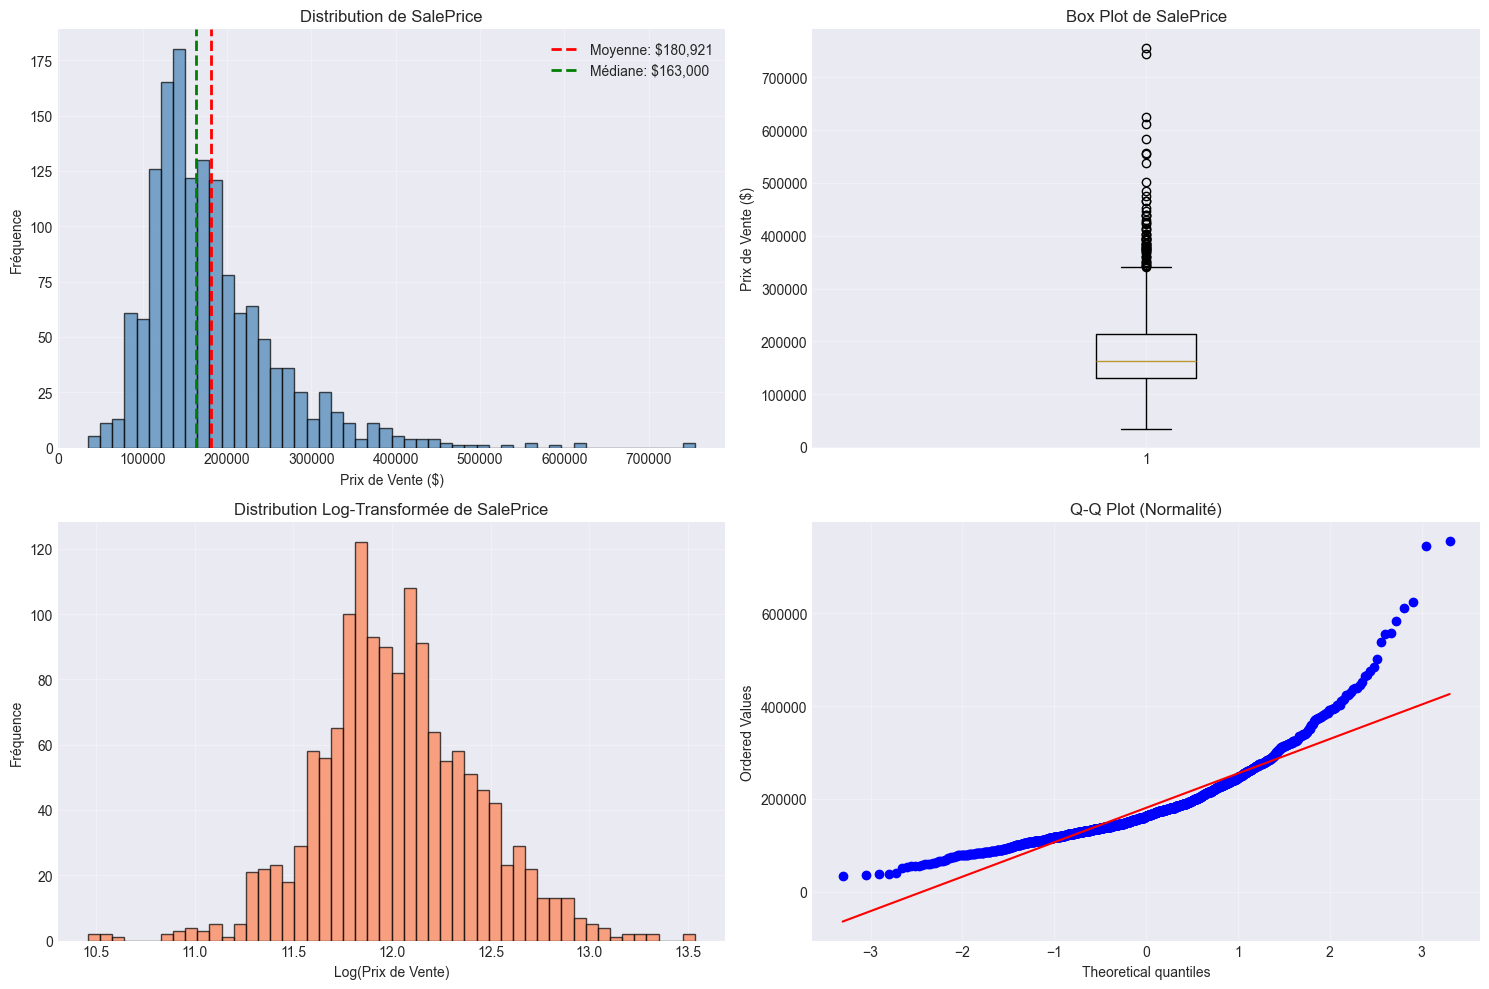


Observation: La distribution est asymetrique a droite
   Une transformation logarithmique peut être bénéfique pour normaliser la distribution.


In [5]:
# Analyse de la variable cible
print("=" * 60)
print("ANALYSE DE LA VARIABLE CIBLE (SalePrice)")
print("=" * 60)

print("\nStatistiques descriptives:")
print(train_df['SalePrice'].describe())

print(f"\nCaracteristiques:")
print(f"   - Minimum: ${train_df['SalePrice'].min():,.2f}")
print(f"   - Maximum: ${train_df['SalePrice'].max():,.2f}")
print(f"   - Moyenne: ${train_df['SalePrice'].mean():,.2f}")
print(f"   - Mediane: ${train_df['SalePrice'].median():,.2f}")
print(f"   - Ecart-type: ${train_df['SalePrice'].std():,.2f}")

print(f"\nDistribution:")
print(f"   - Skewness: {train_df['SalePrice'].skew():.3f} {'(asymétrique à droite)' if train_df['SalePrice'].skew() > 0.5 else '(relativement symétrique)'}")
kurtosis_val = train_df['SalePrice'].kurtosis()
print(f"   - Kurtosis: {kurtosis_val:.3f}")

# Explication du Kurtosis
print(f"\nInterpretation du Kurtosis:")
print(f"   - Kurtosis = 3: Distribution normale (mesokurtique)")
print(f"   - Kurtosis < 3: Distribution avec queues legeres (platikurtique)")
print(f"   - Kurtosis > 3: Distribution avec queues lourdes (leptokurtique)")
print(f"\n   Notre valeur ({kurtosis_val:.3f}) indique:")
if kurtosis_val > 3:
    print(f"   - Distribution LEPTOKURTIQUE (queues tres lourdes)")
    print(f"   - Presence importante de valeurs extremes (outliers)")
    print(f"   - Distribution plus pointue que la normale")
    print(f"   - Necessite une transformation (logarithmique) pour normaliser")
elif kurtosis_val < 3:
    print(f"   - Distribution PLATIKURTIQUE (queues legeres)")
    print(f"   - Moins de valeurs extremes que la normale")
else:
    print(f"   - Distribution MESOKURTIQUE (normale)")

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogramme
axes[0, 0].hist(train_df['SalePrice'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(train_df['SalePrice'].mean(), color='r', linestyle='--', linewidth=2, label=f'Moyenne: ${train_df["SalePrice"].mean():,.0f}')
axes[0, 0].axvline(train_df['SalePrice'].median(), color='g', linestyle='--', linewidth=2, label=f'Médiane: ${train_df["SalePrice"].median():,.0f}')
axes[0, 0].set_xlabel('Prix de Vente ($)')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].set_title('Distribution de SalePrice')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Box plot
axes[0, 1].boxplot(train_df['SalePrice'], vert=True)
axes[0, 1].set_ylabel('Prix de Vente ($)')
axes[0, 1].set_title('Box Plot de SalePrice')
axes[0, 1].grid(True, alpha=0.3)

# Distribution log-transformée
axes[1, 0].hist(np.log1p(train_df['SalePrice']), bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1, 0].set_xlabel('Log(Prix de Vente)')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].set_title('Distribution Log-Transformée de SalePrice')
axes[1, 0].grid(True, alpha=0.3)

# Q-Q plot pour vérifier la normalité
from scipy import stats
stats.probplot(train_df['SalePrice'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normalité)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/saleprice_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nObservation: La distribution est {'asymetrique a droite' if train_df['SalePrice'].skew() > 0.5 else 'relativement symetrique'}")
print(f"   Une transformation logarithmique peut être bénéfique pour normaliser la distribution.")


ANALYSE DES VALEURS MANQUANTES

Colonnes avec valeurs manquantes dans TRAIN: 19

Top 20 colonnes avec le plus de valeurs manquantes:
     Colonne  Valeurs_Manquantes  Pourcentage
      PoolQC                1453    99.520548
 MiscFeature                1406    96.301370
       Alley                1369    93.767123
       Fence                1179    80.753425
  MasVnrType                 872    59.726027
 FireplaceQu                 690    47.260274
 LotFrontage                 259    17.739726
  GarageQual                  81     5.547945
GarageFinish                  81     5.547945
  GarageType                  81     5.547945
 GarageYrBlt                  81     5.547945
  GarageCond                  81     5.547945
BsmtFinType2                  38     2.602740
BsmtExposure                  38     2.602740
    BsmtCond                  37     2.534247
    BsmtQual                  37     2.534247
BsmtFinType1                  37     2.534247
  MasVnrArea                   8     0.

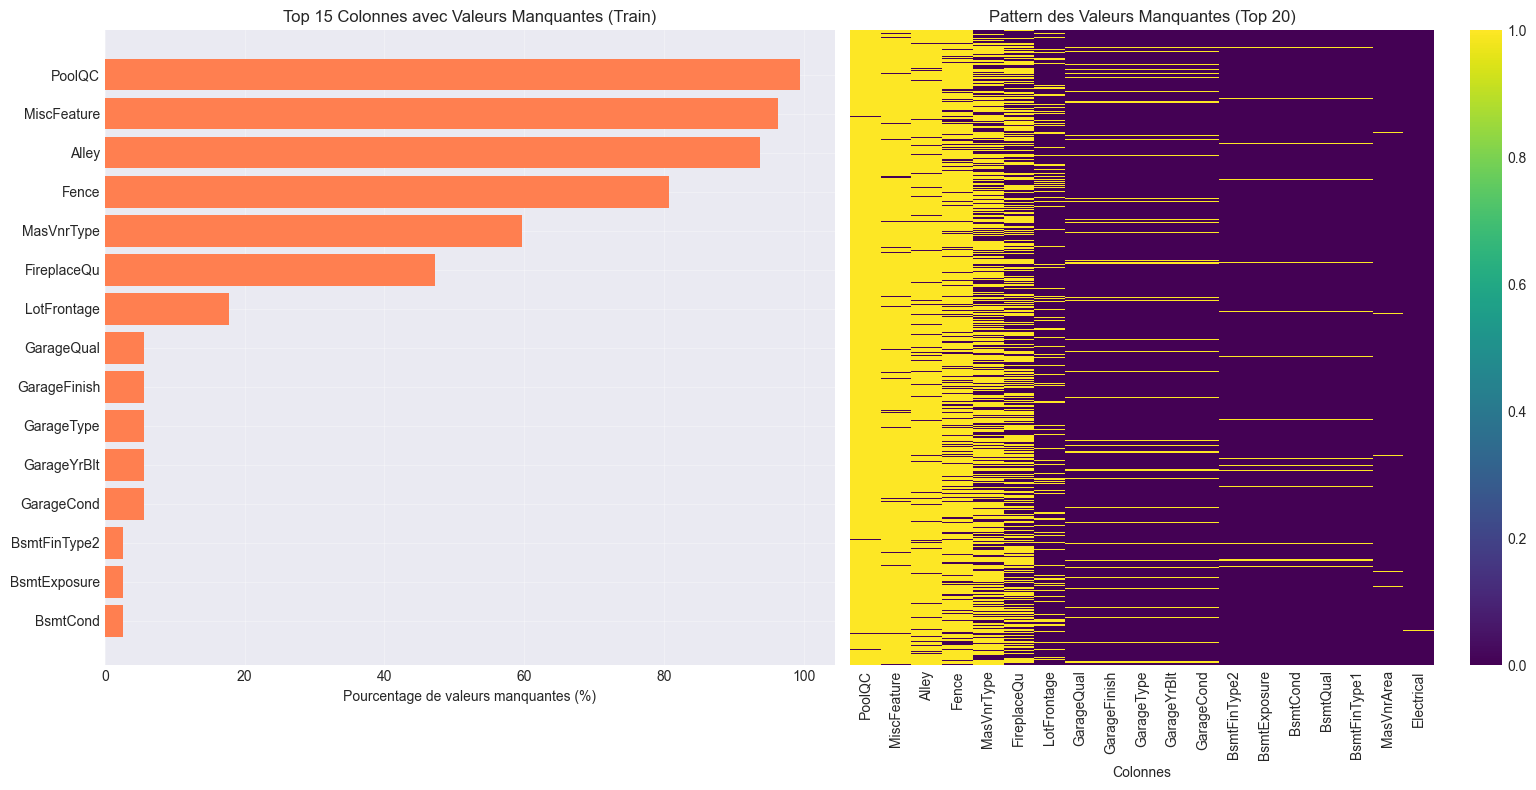


Observations:
   - 19 colonnes contiennent des valeurs manquantes
   - La colonne avec le plus de valeurs manquantes: PoolQC (99.5%)

VARIABLES SANS VALEURS MANQUANTES

Nombre de variables sans valeurs manquantes: 62
Sur un total de 81 variables

Variables numeriques sans valeurs manquantes (35):
     1. Id
     2. MSSubClass
     3. LotArea
     4. OverallQual
     5. OverallCond
     6. YearBuilt
     7. YearRemodAdd
     8. BsmtFinSF1
     9. BsmtFinSF2
    10. BsmtUnfSF
    11. TotalBsmtSF
    12. 1stFlrSF
    13. 2ndFlrSF
    14. LowQualFinSF
    15. GrLivArea
    16. BsmtFullBath
    17. BsmtHalfBath
    18. FullBath
    19. HalfBath
    20. BedroomAbvGr
    21. KitchenAbvGr
    22. TotRmsAbvGrd
    23. Fireplaces
    24. GarageCars
    25. GarageArea
    26. WoodDeckSF
    27. OpenPorchSF
    28. EnclosedPorch
    29. 3SsnPorch
    30. ScreenPorch
    31. PoolArea
    32. MiscVal
    33. MoSold
    34. YrSold
    35. SalePrice

Variables categorielles sans valeurs manquantes (2

In [6]:
# Analyse des valeurs manquantes
print("=" * 60)
print("ANALYSE DES VALEURS MANQUANTES")
print("=" * 60)

missing_train = train_df.isnull().sum()
missing_pct_train = (missing_train / len(train_df)) * 100
missing_df_train = pd.DataFrame({
    'Colonne': missing_train.index,
    'Valeurs_Manquantes': missing_train.values,
    'Pourcentage': missing_pct_train.values
}).sort_values('Valeurs_Manquantes', ascending=False)

missing_df_train = missing_df_train[missing_df_train['Valeurs_Manquantes'] > 0]

print(f"\nColonnes avec valeurs manquantes dans TRAIN: {len(missing_df_train)}")
print(f"\nTop 20 colonnes avec le plus de valeurs manquantes:")
print(missing_df_train.head(20).to_string(index=False))

# Visualisation
if len(missing_df_train) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Bar plot
    top_missing = missing_df_train.head(15)
    axes[0].barh(range(len(top_missing)), top_missing['Pourcentage'], color='coral')
    axes[0].set_yticks(range(len(top_missing)))
    axes[0].set_yticklabels(top_missing['Colonne'])
    axes[0].set_xlabel('Pourcentage de valeurs manquantes (%)')
    axes[0].set_title('Top 15 Colonnes avec Valeurs Manquantes (Train)')
    axes[0].invert_yaxis()
    axes[0].grid(True, alpha=0.3)
    
    # Heatmap des valeurs manquantes
    missing_cols = missing_df_train.head(20)['Colonne'].tolist()
    missing_matrix = train_df[missing_cols].isnull()
    sns.heatmap(missing_matrix, yticklabels=False, cbar=True, ax=axes[1], cmap='viridis')
    axes[1].set_title('Pattern des Valeurs Manquantes (Top 20)')
    axes[1].set_xlabel('Colonnes')
    
    plt.tight_layout()
    plt.savefig('../output/figures/missing_values_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nObservations:")
    print(f"   - {len(missing_df_train)} colonnes contiennent des valeurs manquantes")
    print(f"   - La colonne avec le plus de valeurs manquantes: {missing_df_train.iloc[0]['Colonne']} ({missing_df_train.iloc[0]['Pourcentage']:.1f}%)")
else:
    print("\nAucune valeur manquante dans le dataset d'entrainement!")

# Variables sans valeurs manquantes
print("\n" + "=" * 60)
print("VARIABLES SANS VALEURS MANQUANTES")
print("=" * 60)

no_missing = train_df.columns[train_df.isnull().sum() == 0].tolist()
print(f"\nNombre de variables sans valeurs manquantes: {len(no_missing)}")
print(f"Sur un total de {len(train_df.columns)} variables\n")

# Séparer par type
no_missing_numeric = [col for col in no_missing if train_df[col].dtype in ['int64', 'float64']]
no_missing_categorical = [col for col in no_missing if train_df[col].dtype == 'object']

print(f"Variables numeriques sans valeurs manquantes ({len(no_missing_numeric)}):")
for i, col in enumerate(no_missing_numeric, 1):
    print(f"   {i:3d}. {col}")

print(f"\nVariables categorielles sans valeurs manquantes ({len(no_missing_categorical)}):")
for i, col in enumerate(no_missing_categorical, 1):
    print(f"   {i:3d}. {col}")

# Sauvegarder la liste
no_missing_df = pd.DataFrame({
    'Variable': no_missing,
    'Type': ['Numerique' if col in no_missing_numeric else 'Categorielle' for col in no_missing]
})
no_missing_df.to_csv('../output/tables/variables_sans_valeurs_manquantes.csv', index=False)
print(f"\nListe sauvegardee dans: output/tables/variables_sans_valeurs_manquantes.csv")


In [7]:
# Catégorisation des variables
print("=" * 60)
print("CATÉGORISATION DES VARIABLES")
print("=" * 60)

# Définir les catégories
categories = {
    'Identifiant': ['Id'],
    'Caractéristiques Physiques': [
        'MSSubClass', 'LotFrontage', 'LotArea', 'LotShape', 'LandContour', 
        'LotConfig', 'LandSlope', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 
        'GrLivArea', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd'
    ],
    'Localisation': [
        'MSZoning', 'Street', 'Alley', 'Neighborhood', 'Condition1', 'Condition2'
    ],
    'Type et Style': [
        'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 
        'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea'
    ],
    'Qualité et Condition': [
        'OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 
        'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 
        'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual', 
        'Functional', 'FireplaceQu', 'GarageQual', 'GarageCond', 
        'PoolQC', 'Fence'
    ],
    'Sous-sol': [
        'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 
        'BsmtFullBath', 'BsmtHalfBath'
    ],
    'Garage': [
        'GarageType', 'GarageYrBlt', 'GarageFinish', 
        'GarageCars', 'GarageArea'
    ],
    'Salles de bain': [
        'FullBath', 'HalfBath'
    ],
    'Systèmes': [
        'Utilities', 'Heating', 'CentralAir', 'Electrical', 'PavedDrive'
    ],
    'Extérieur': [
        'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 
        '3SsnPorch', 'ScreenPorch', 'PoolArea'
    ],
    'Divers': [
        'Fireplaces', 'MiscFeature', 'MiscVal'
    ],
    'Temporel': [
        'YearBuilt', 'YearRemodAdd', 'MoSold', 'YrSold'
    ],
    'Transaction': [
        'SaleType', 'SaleCondition'
    ],
    'Cible': [
        'SalePrice'
    ]
}

print("\nRepartition des variables par categorie:\n")
for category, vars_list in categories.items():
    existing_vars = [v for v in vars_list if v in train_df.columns]
    if existing_vars:
        print(f"   {category}: {len(existing_vars)} variables")
        print(f"      {', '.join(existing_vars[:5])}")
        if len(existing_vars) > 5:
            print(f"      ... et {len(existing_vars) - 5} autres")
        print()


CATÉGORISATION DES VARIABLES

Repartition des variables par categorie:

   Identifiant: 1 variables
      Id

   Caractéristiques Physiques: 14 variables
      MSSubClass, LotFrontage, LotArea, LotShape, LandContour
      ... et 9 autres

   Localisation: 6 variables
      MSZoning, Street, Alley, Neighborhood, Condition1
      ... et 1 autres

   Type et Style: 8 variables
      BldgType, HouseStyle, RoofStyle, RoofMatl, Exterior1st
      ... et 3 autres

   Qualité et Condition: 18 variables
      OverallQual, OverallCond, ExterQual, ExterCond, Foundation
      ... et 13 autres

   Sous-sol: 6 variables
      BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, BsmtFullBath
      ... et 1 autres

   Garage: 5 variables
      GarageType, GarageYrBlt, GarageFinish, GarageCars, GarageArea

   Salles de bain: 2 variables
      FullBath, HalfBath

   Systèmes: 5 variables
      Utilities, Heating, CentralAir, Electrical, PavedDrive

   Extérieur: 6 variables
      WoodDeckSF, OpenPorchSF, Encl

## 6. Variables Numériques Clés


VARIABLES NUMÉRIQUES CLÉS

Statistiques descriptives des variables cles:

       GrLivArea  TotalBsmtSF    LotArea  OverallQual  OverallCond  YearBuilt  \
count    1460.00      1460.00    1460.00      1460.00      1460.00    1460.00   
mean     1515.46      1057.43   10516.83         6.10         5.58    1971.27   
std       525.48       438.71    9981.26         1.38         1.11      30.20   
min       334.00         0.00    1300.00         1.00         1.00    1872.00   
25%      1129.50       795.75    7553.50         5.00         5.00    1954.00   
50%      1464.00       991.50    9478.50         6.00         5.00    1973.00   
75%      1776.75      1298.25   11601.50         7.00         6.00    2000.00   
max      5642.00      6110.00  215245.00        10.00         9.00    2010.00   

       GarageArea  1stFlrSF  FullBath  TotRmsAbvGrd  YearRemodAdd  GarageCars  
count     1460.00   1460.00   1460.00       1460.00       1460.00     1460.00  
mean       472.98   1162.63      1.5

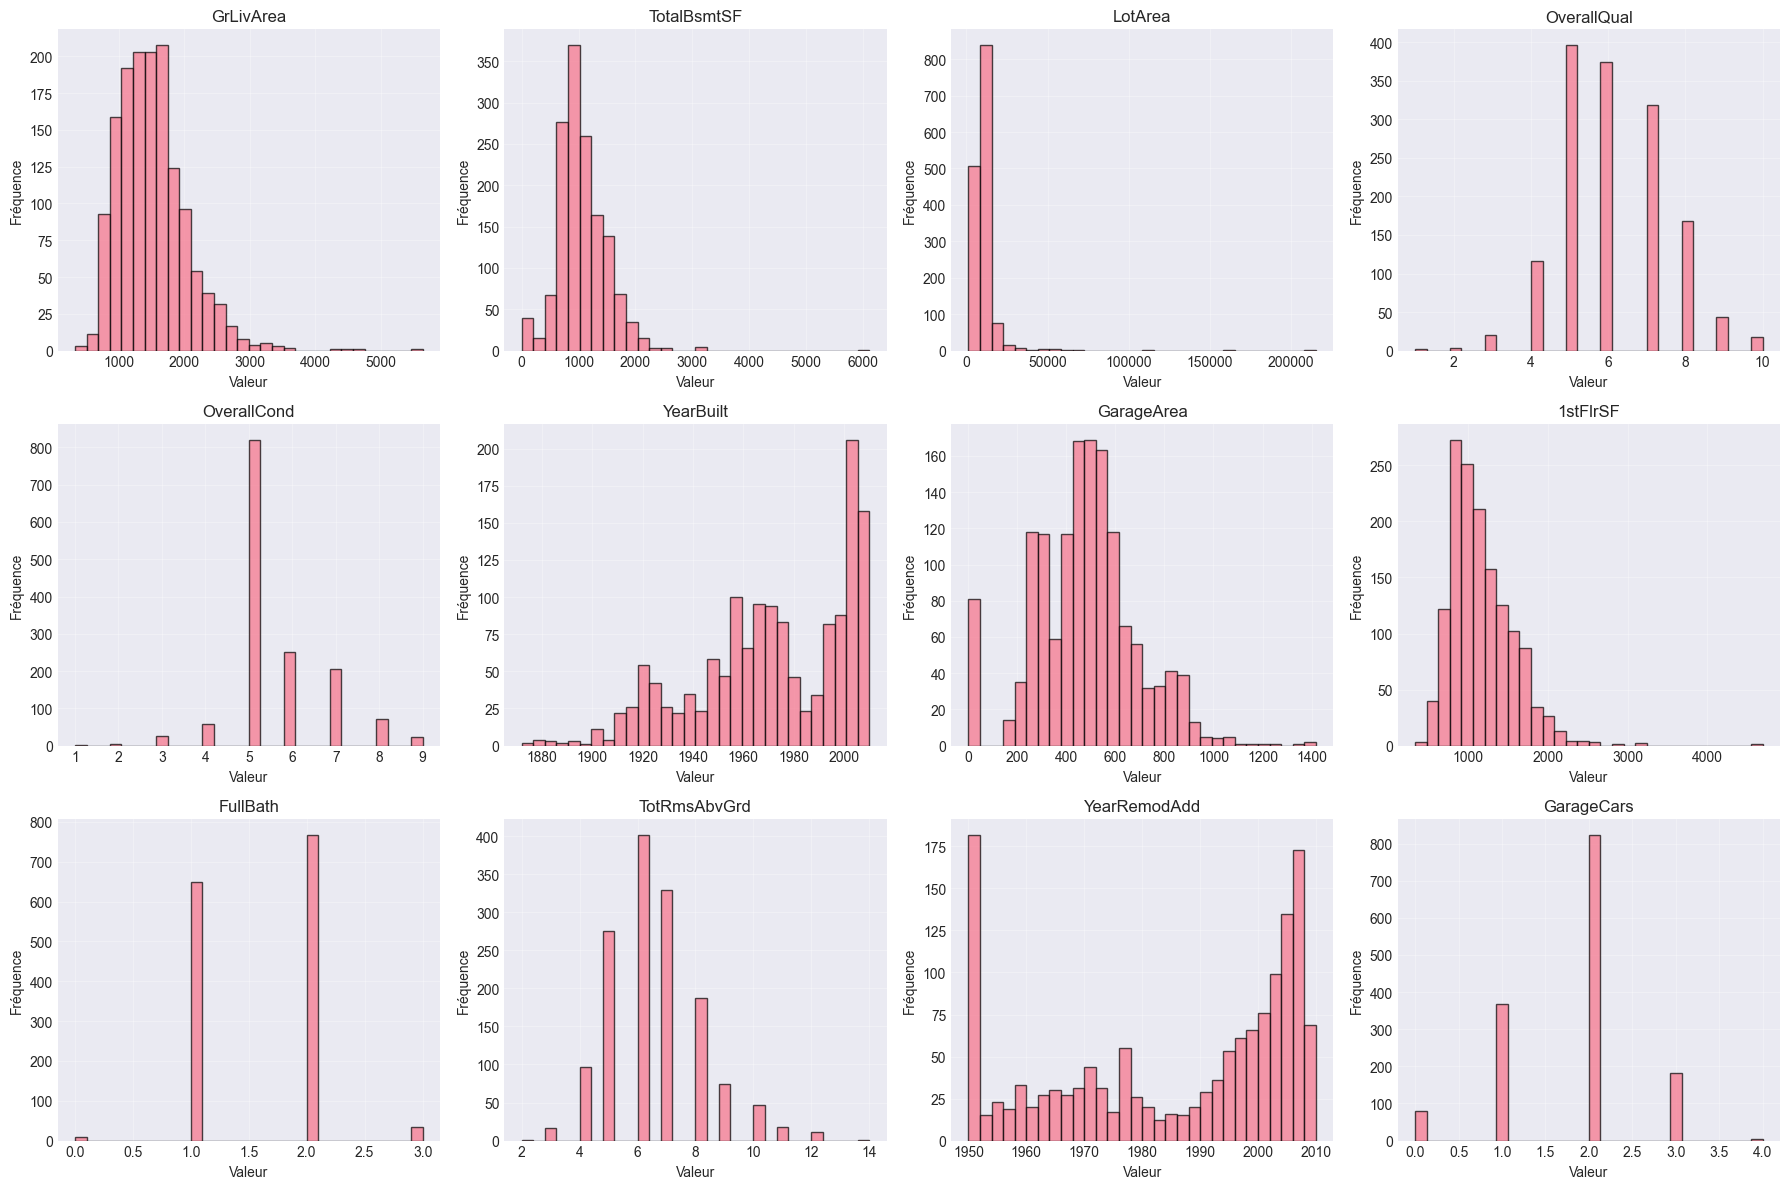

In [8]:
# Analyse des variables numériques importantes
print("=" * 60)
print("VARIABLES NUMÉRIQUES CLÉS")
print("=" * 60)

key_numeric_vars = ['GrLivArea', 'TotalBsmtSF', 'LotArea', 'OverallQual', 
                     'OverallCond', 'YearBuilt', 'GarageArea', '1stFlrSF', 
                     'FullBath', 'TotRmsAbvGrd', 'YearRemodAdd', 'GarageCars']

existing_key_vars = [v for v in key_numeric_vars if v in train_df.columns]

print("\nStatistiques descriptives des variables cles:\n")
print(train_df[existing_key_vars].describe().round(2))

# Visualisation des distributions
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, var in enumerate(existing_key_vars[:12]):
    axes[idx].hist(train_df[var].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{var}')
    axes[idx].set_xlabel('Valeur')
    axes[idx].set_ylabel('Fréquence')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/key_numeric_vars_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. Variables Catégorielles Clés


VARIABLES CATÉGORIELLES CLÉS

MSZoning:
   Nombre de catégories: 5
   Top 5 valeurs:
      RL: 1151 (78.8%)
      RM: 218 (14.9%)
      FV: 65 (4.5%)
      RH: 16 (1.1%)
      C (all): 10 (0.7%)


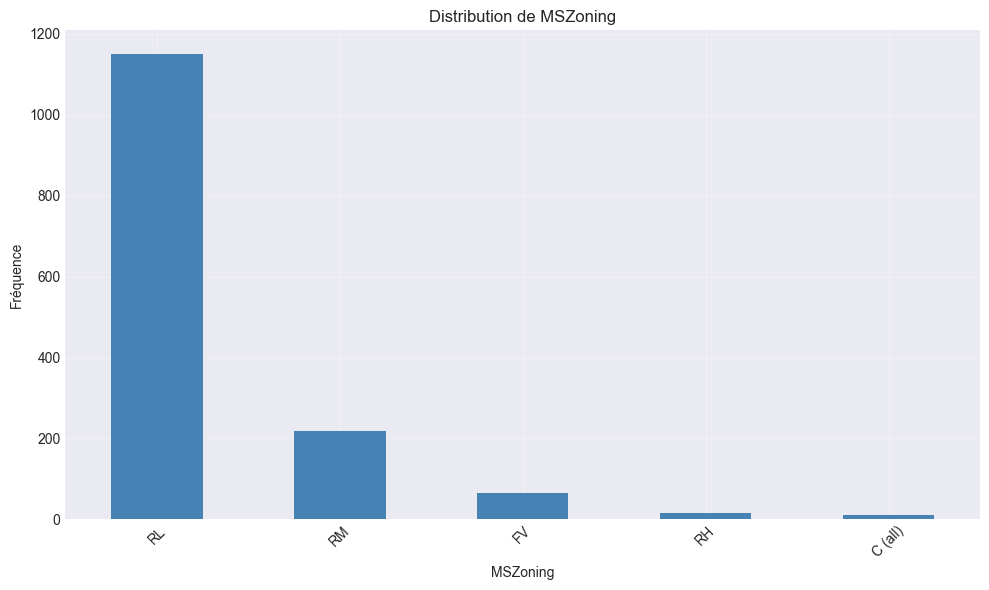


Neighborhood:
   Nombre de catégories: 25
   Top 5 valeurs:
      NAmes: 225 (15.4%)
      CollgCr: 150 (10.3%)
      OldTown: 113 (7.7%)
      Edwards: 100 (6.8%)
      Somerst: 86 (5.9%)

BldgType:
   Nombre de catégories: 5
   Top 5 valeurs:
      1Fam: 1220 (83.6%)
      TwnhsE: 114 (7.8%)
      Duplex: 52 (3.6%)
      Twnhs: 43 (2.9%)
      2fmCon: 31 (2.1%)


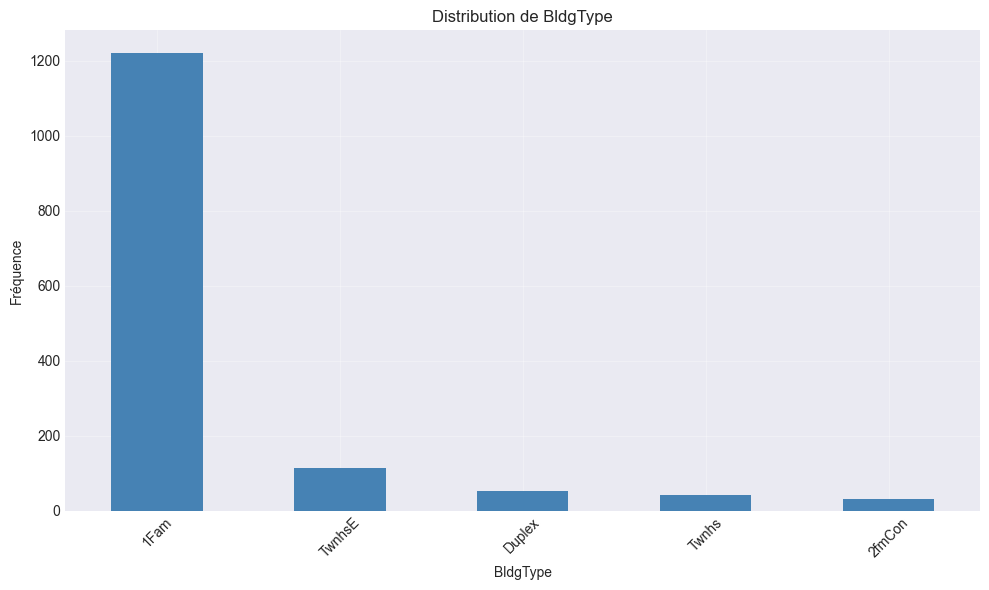


HouseStyle:
   Nombre de catégories: 8
   Top 5 valeurs:
      1Story: 726 (49.7%)
      2Story: 445 (30.5%)
      1.5Fin: 154 (10.5%)
      SLvl: 65 (4.5%)
      SFoyer: 37 (2.5%)


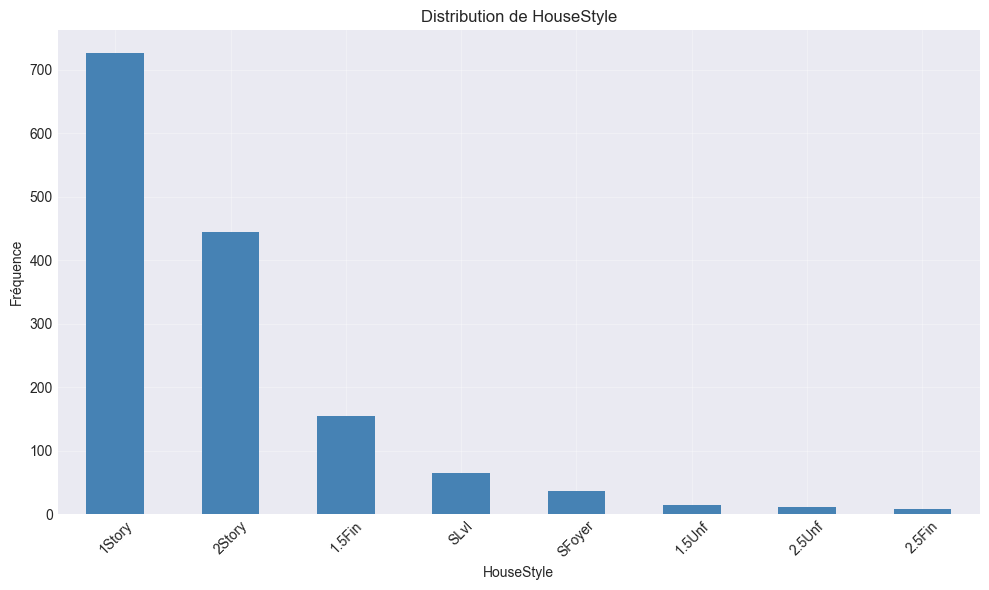


ExterQual:
   Nombre de catégories: 4
   Top 5 valeurs:
      TA: 906 (62.1%)
      Gd: 488 (33.4%)
      Ex: 52 (3.6%)
      Fa: 14 (1.0%)


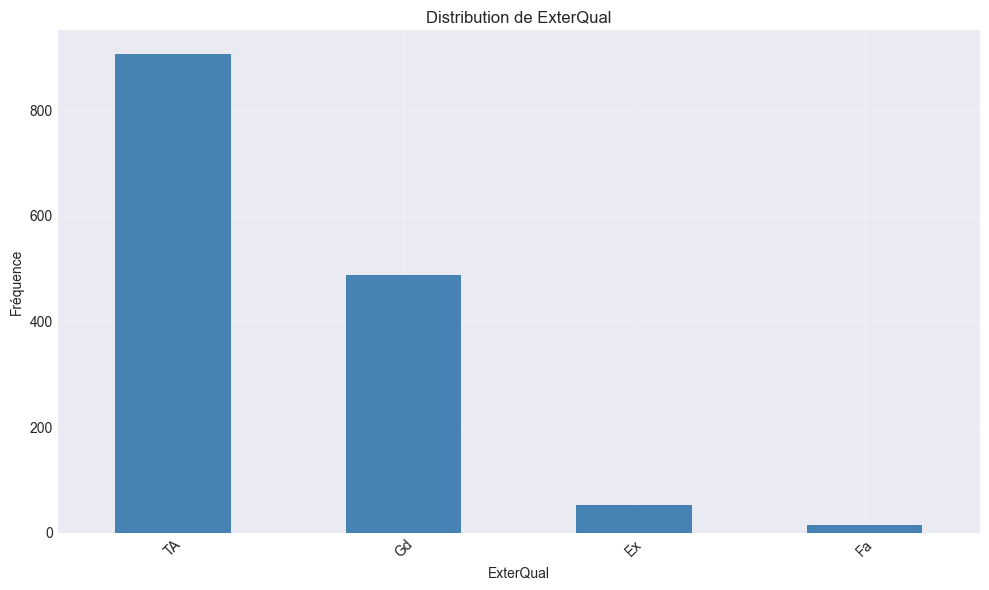


KitchenQual:
   Nombre de catégories: 4
   Top 5 valeurs:
      TA: 735 (50.3%)
      Gd: 586 (40.1%)
      Ex: 100 (6.8%)
      Fa: 39 (2.7%)


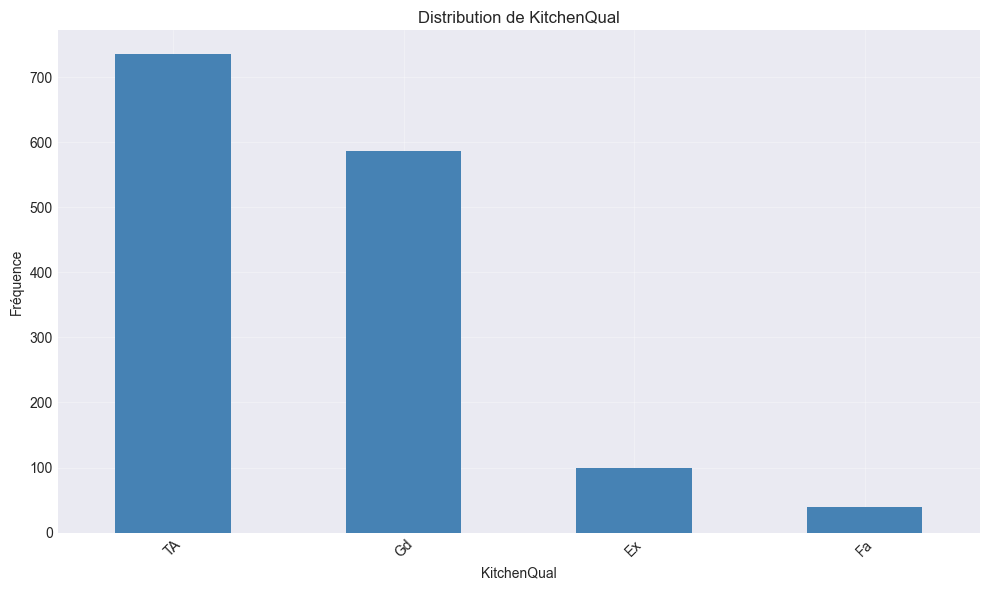


SaleType:
   Nombre de catégories: 9
   Top 5 valeurs:
      WD: 1267 (86.8%)
      New: 122 (8.4%)
      COD: 43 (2.9%)
      ConLD: 9 (0.6%)
      ConLI: 5 (0.3%)


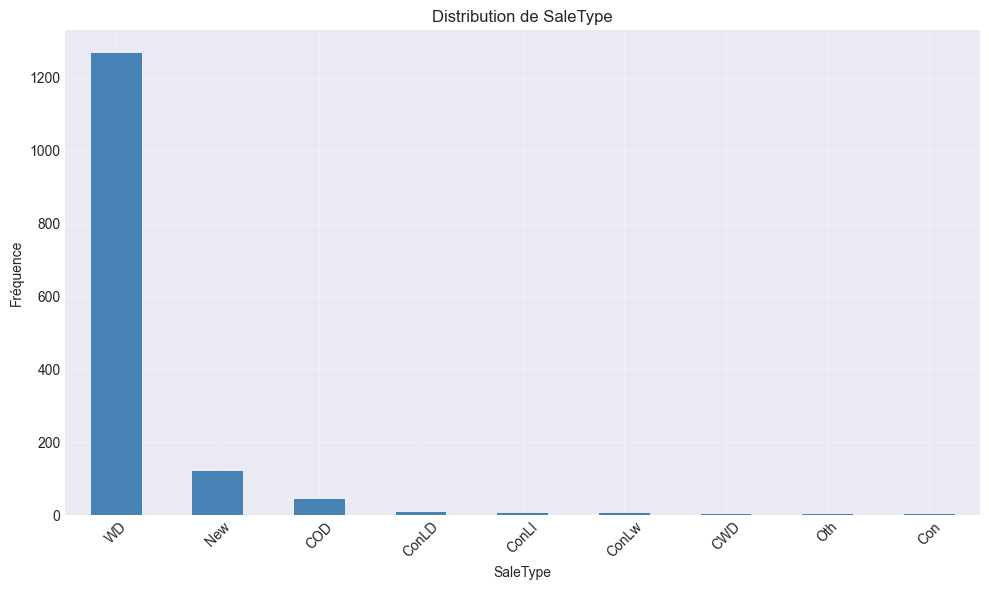


SaleCondition:
   Nombre de catégories: 6
   Top 5 valeurs:
      Normal: 1198 (82.1%)
      Partial: 125 (8.6%)
      Abnorml: 101 (6.9%)
      Family: 20 (1.4%)
      Alloca: 12 (0.8%)


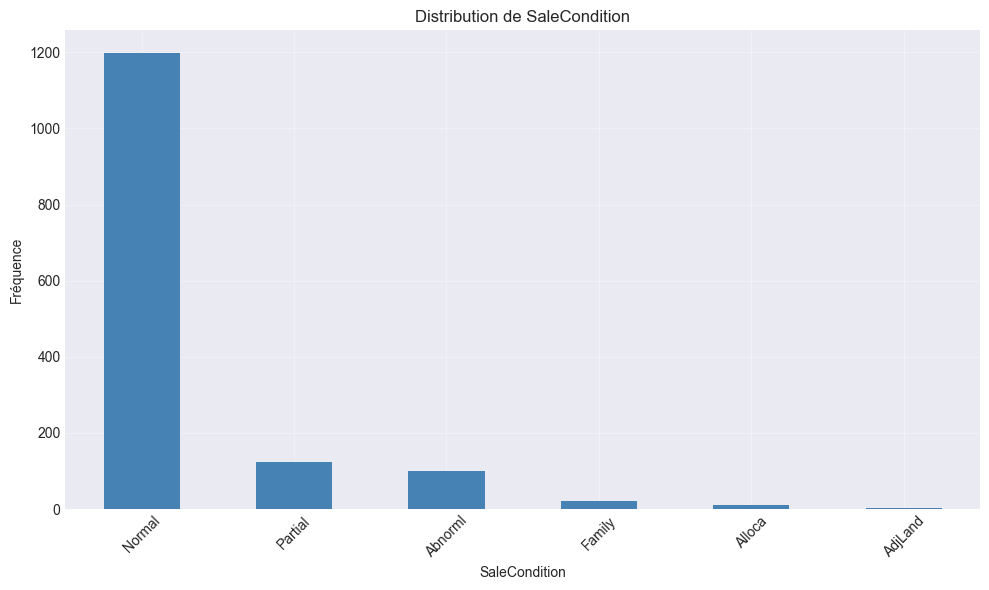

In [9]:
# Analyse des variables catégorielles importantes
print("=" * 60)
print("VARIABLES CATÉGORIELLES CLÉS")
print("=" * 60)

key_categorical_vars = ['MSZoning', 'Neighborhood', 'BldgType', 'HouseStyle', 
                        'ExterQual', 'KitchenQual', 'SaleType', 'SaleCondition']

existing_cat_vars = [v for v in key_categorical_vars if v in train_df.columns]

for var in existing_cat_vars:
    print(f"\n{var}:")
    value_counts = train_df[var].value_counts()
    print(f"   Nombre de catégories: {train_df[var].nunique()}")
    print(f"   Top 5 valeurs:")
    for val, count in value_counts.head().items():
        pct = (count / len(train_df)) * 100
        print(f"      {val}: {count} ({pct:.1f}%)")
    
    # Visualisation
    if train_df[var].nunique() <= 20:  # Seulement si pas trop de catégories
        fig, ax = plt.subplots(figsize=(10, 6))
        value_counts.head(10).plot(kind='bar', ax=ax, color='steelblue')
        ax.set_title(f'Distribution de {var}')
        ax.set_xlabel(var)
        ax.set_ylabel('Fréquence')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'../output/figures/categorical_{var}.png', dpi=300, bbox_inches='tight')
        plt.show()


## 8. Corrélations avec la Variable Cible


CORRÉLATIONS AVEC SALEPRICE

Top 20 variables les plus correlees avec SalePrice:

   OverallQual         :  0.791 (forte)
   GrLivArea           :  0.709 (forte)
   GarageCars          :  0.640 (forte)
   GarageArea          :  0.623 (forte)
   TotalBsmtSF         :  0.614 (forte)
   1stFlrSF            :  0.606 (forte)
   FullBath            :  0.561 (forte)
   TotRmsAbvGrd        :  0.534 (forte)
   YearBuilt           :  0.523 (forte)
   YearRemodAdd        :  0.507 (forte)
   GarageYrBlt         :  0.486 (moderee)
   MasVnrArea          :  0.477 (moderee)
   Fireplaces          :  0.467 (moderee)
   BsmtFinSF1          :  0.386 (moderee)
   LotFrontage         :  0.352 (moderee)
   WoodDeckSF          :  0.324 (moderee)
   2ndFlrSF            :  0.319 (moderee)
   OpenPorchSF         :  0.316 (moderee)
   HalfBath            :  0.284 (faible)

Bottom 10 variables les moins correlees avec SalePrice:

   3SsnPorch           :  0.045
   BsmtFinSF2          : -0.011
   BsmtHalfBath    

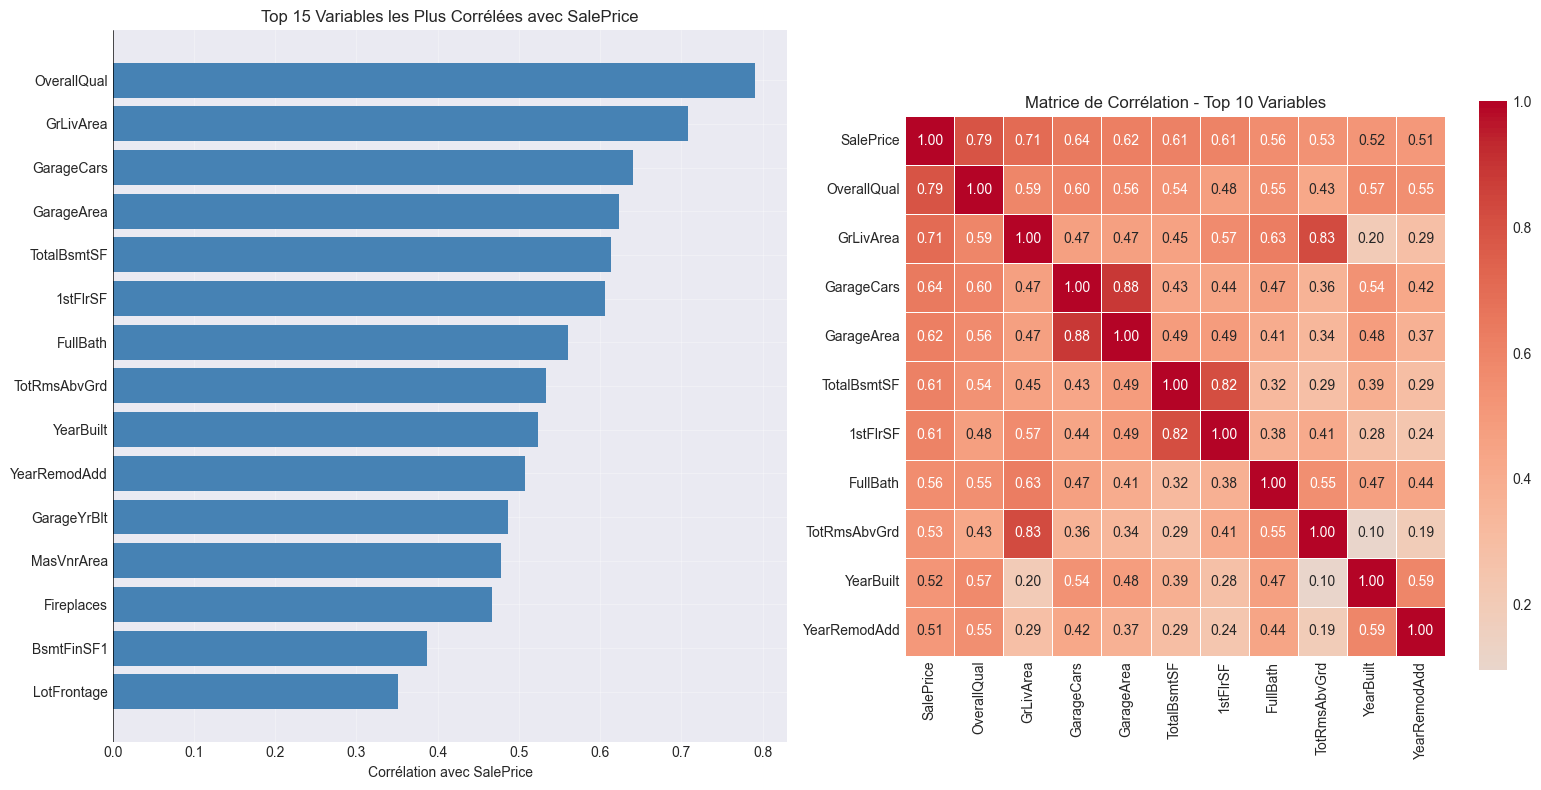


Observations:
   - Variable la plus corrélée: OverallQual (0.791)
   - 10 variables ont une corrélation forte (|r| > 0.5) avec SalePrice
   - 18 variables ont une corrélation modérée (|r| > 0.3) avec SalePrice


In [10]:
# Corrélations avec SalePrice
print("=" * 60)
print("CORRÉLATIONS AVEC SALEPRICE")
print("=" * 60)

# Calculer les corrélations
correlations = train_df[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)

print("\nTop 20 variables les plus correlees avec SalePrice:\n")
top_corr = correlations.head(20)
for var, corr in top_corr.items():
    if var != 'SalePrice':
        print(f"   {var:20s}: {corr:6.3f} {'(forte)' if abs(corr) > 0.5 else '(moderee)' if abs(corr) > 0.3 else '(faible)'}")

print("\nBottom 10 variables les moins correlees avec SalePrice:\n")
bottom_corr = correlations.tail(11)  # 11 car SalePrice est inclus
for var, corr in bottom_corr.items():
    if var != 'SalePrice':
        print(f"   {var:20s}: {corr:6.3f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top corrélations
top_15 = correlations.head(16).drop('SalePrice')  # Exclure SalePrice
axes[0].barh(range(len(top_15)), top_15.values, color='steelblue')
axes[0].set_yticks(range(len(top_15)))
axes[0].set_yticklabels(top_15.index)
axes[0].set_xlabel('Corrélation avec SalePrice')
axes[0].set_title('Top 15 Variables les Plus Corrélées avec SalePrice')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Matrice de corrélation des top variables
top_corr_vars = correlations.head(11).index.tolist()  # Top 10 + SalePrice
corr_matrix = train_df[top_corr_vars].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=axes[1])
axes[1].set_title('Matrice de Corrélation - Top 10 Variables')

plt.tight_layout()
plt.savefig('../output/figures/correlations_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nObservations:")
print(f"   - Variable la plus corrélée: {correlations.drop('SalePrice').index[0]} ({correlations.drop('SalePrice').iloc[0]:.3f})")
print(f"   - {len(correlations[abs(correlations) > 0.5]) - 1} variables ont une corrélation forte (|r| > 0.5) avec SalePrice")
print(f"   - {len(correlations[abs(correlations) > 0.3]) - 1} variables ont une corrélation modérée (|r| > 0.3) avec SalePrice")


## 9. Détection des Outliers


DÉTECTION DES OUTLIERS

Outliers detectes (methode IQR):

   GrLivArea: 31 outliers (2.12%)
   TotalBsmtSF: 61 outliers (4.18%)
   LotArea: 69 outliers (4.73%)
   SalePrice: 61 outliers (4.18%)

   Variable  Outliers Pourcentage Limite Inf Limite Sup
  GrLivArea        31       2.12%     158.62    2747.62
TotalBsmtSF        61       4.18%      42.00    2052.00
    LotArea        69       4.73%    1481.50   17673.50
  SalePrice        61       4.18%    3937.50  340037.50


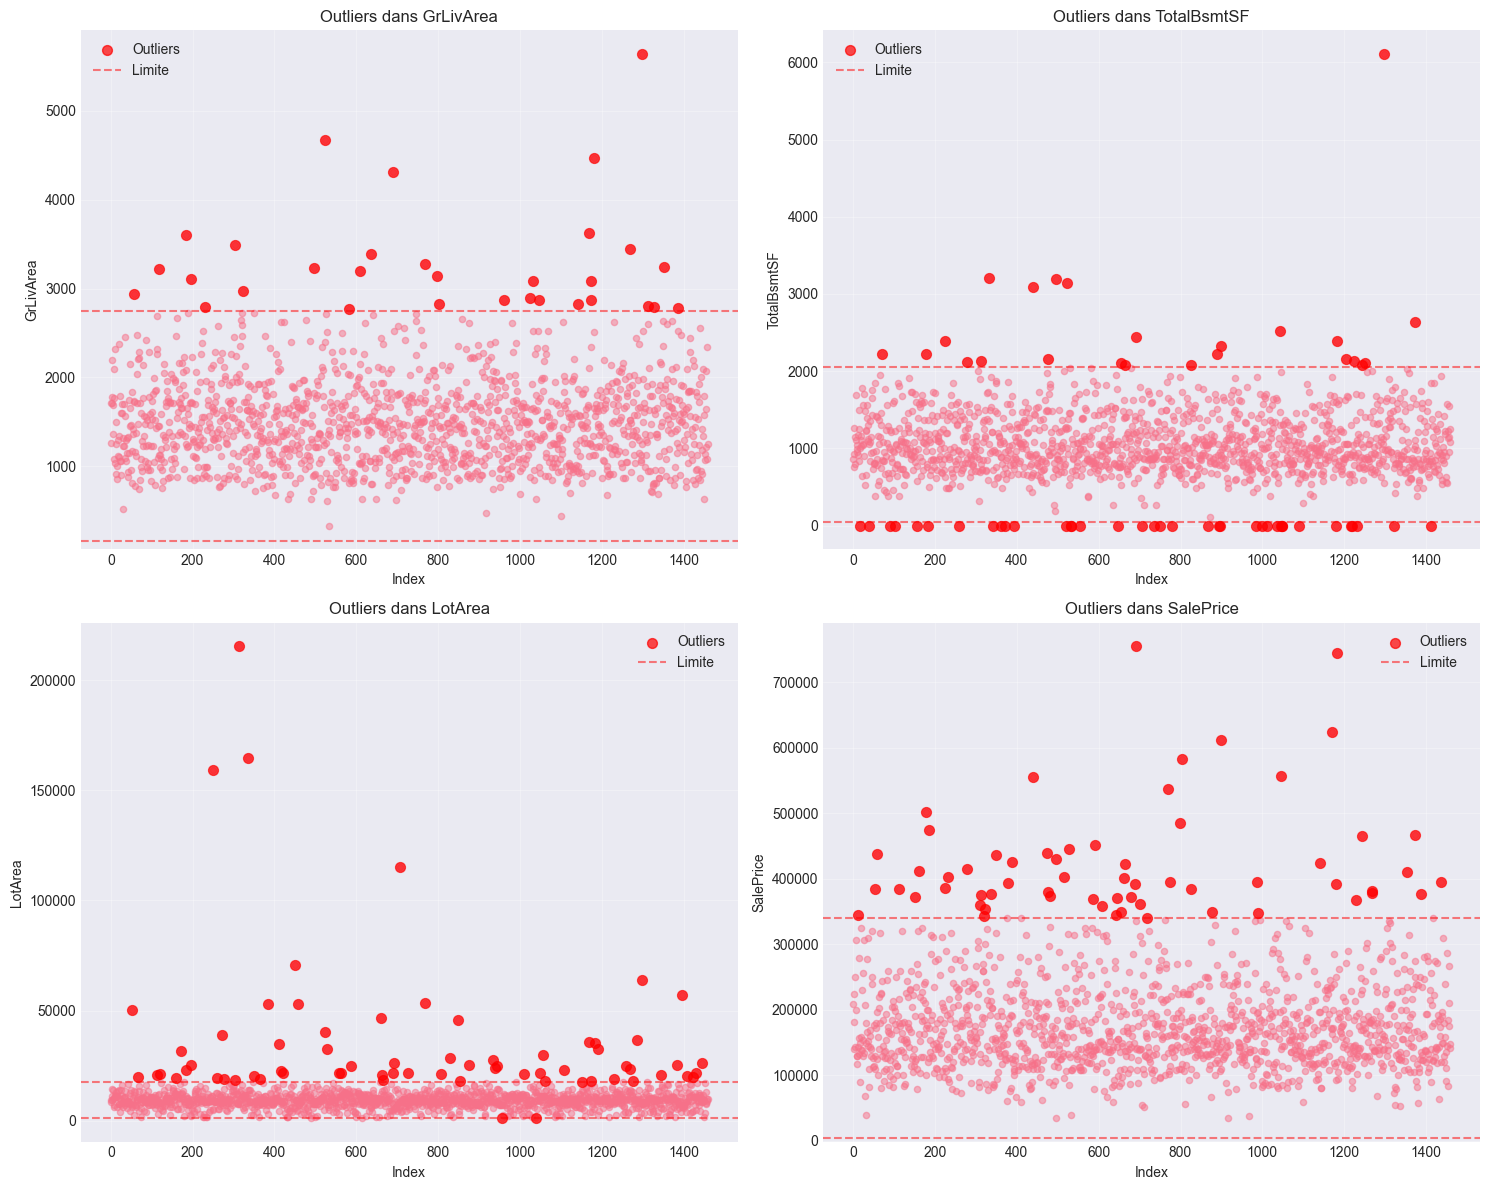


Analyse specifique: GrLivArea vs SalePrice
   Maisons avec GrLivArea > 4000 et SalePrice < 300000: 2


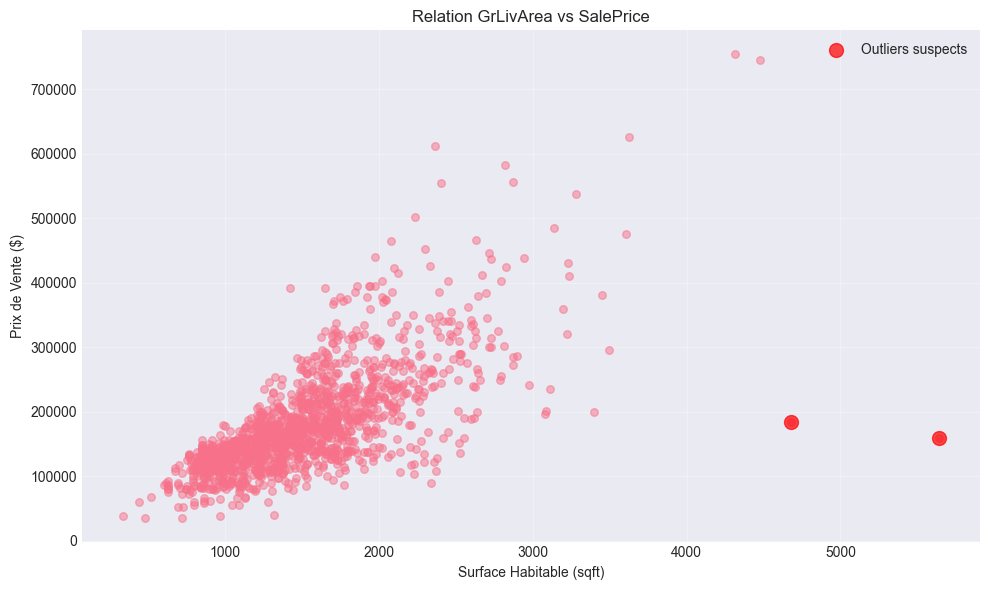

In [11]:
# Détection des outliers
print("=" * 60)
print("DÉTECTION DES OUTLIERS")
print("=" * 60)

# Méthode IQR pour les variables numériques clés
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

key_vars_for_outliers = ['GrLivArea', 'TotalBsmtSF', 'LotArea', 'SalePrice']

print("\nOutliers detectes (methode IQR):\n")
outliers_summary = []

for var in key_vars_for_outliers:
    if var in train_df.columns:
        outliers, lower, upper = detect_outliers_iqr(train_df, var)
        pct = (len(outliers) / len(train_df)) * 100
        outliers_summary.append({
            'Variable': var,
            'Outliers': len(outliers),
            'Pourcentage': f'{pct:.2f}%',
            'Limite Inf': f'{lower:.2f}',
            'Limite Sup': f'{upper:.2f}'
        })
        print(f"   {var}: {len(outliers)} outliers ({pct:.2f}%)")

outliers_df = pd.DataFrame(outliers_summary)
print("\n" + outliers_df.to_string(index=False))

# Visualisation des outliers
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for idx, var in enumerate(key_vars_for_outliers):
    if var in train_df.columns:
        row = idx // 2
        col = idx % 2
        
        # Scatter plot avec outliers
        axes[row, col].scatter(train_df.index, train_df[var], alpha=0.5, s=20)
        
        # Identifier et marquer les outliers
        outliers, lower, upper = detect_outliers_iqr(train_df, var)
        if len(outliers) > 0:
            axes[row, col].scatter(outliers.index, outliers[var], 
                                  color='red', s=50, alpha=0.7, label='Outliers')
            axes[row, col].axhline(y=upper, color='r', linestyle='--', alpha=0.5, label='Limite')
            axes[row, col].axhline(y=lower, color='r', linestyle='--', alpha=0.5)
        
        axes[row, col].set_xlabel('Index')
        axes[row, col].set_ylabel(var)
        axes[row, col].set_title(f'Outliers dans {var}')
        axes[row, col].legend()
        axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/outliers_detection.png', dpi=300, bbox_inches='tight')
plt.show()

# Outliers spécifiques pour GrLivArea vs SalePrice
if 'GrLivArea' in train_df.columns and 'SalePrice' in train_df.columns:
    print("\nAnalyse specifique: GrLivArea vs SalePrice")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(train_df['GrLivArea'], train_df['SalePrice'], alpha=0.5, s=30)
    
    # Identifier les outliers (grande surface mais prix bas)
    outliers_grliv = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)]
    if len(outliers_grliv) > 0:
        ax.scatter(outliers_grliv['GrLivArea'], outliers_grliv['SalePrice'], 
                  color='red', s=100, alpha=0.7, label='Outliers suspects')
        print(f"   Maisons avec GrLivArea > 4000 et SalePrice < 300000: {len(outliers_grliv)}")
    
    ax.set_xlabel('Surface Habitable (sqft)')
    ax.set_ylabel('Prix de Vente ($)')
    ax.set_title('Relation GrLivArea vs SalePrice')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../output/figures/grlivarea_vs_saleprice.png', dpi=300, bbox_inches='tight')
    plt.show()


## 10. Relations entre Variables Clés et Prix


RELATIONS VARIABLES CLÉS vs PRIX


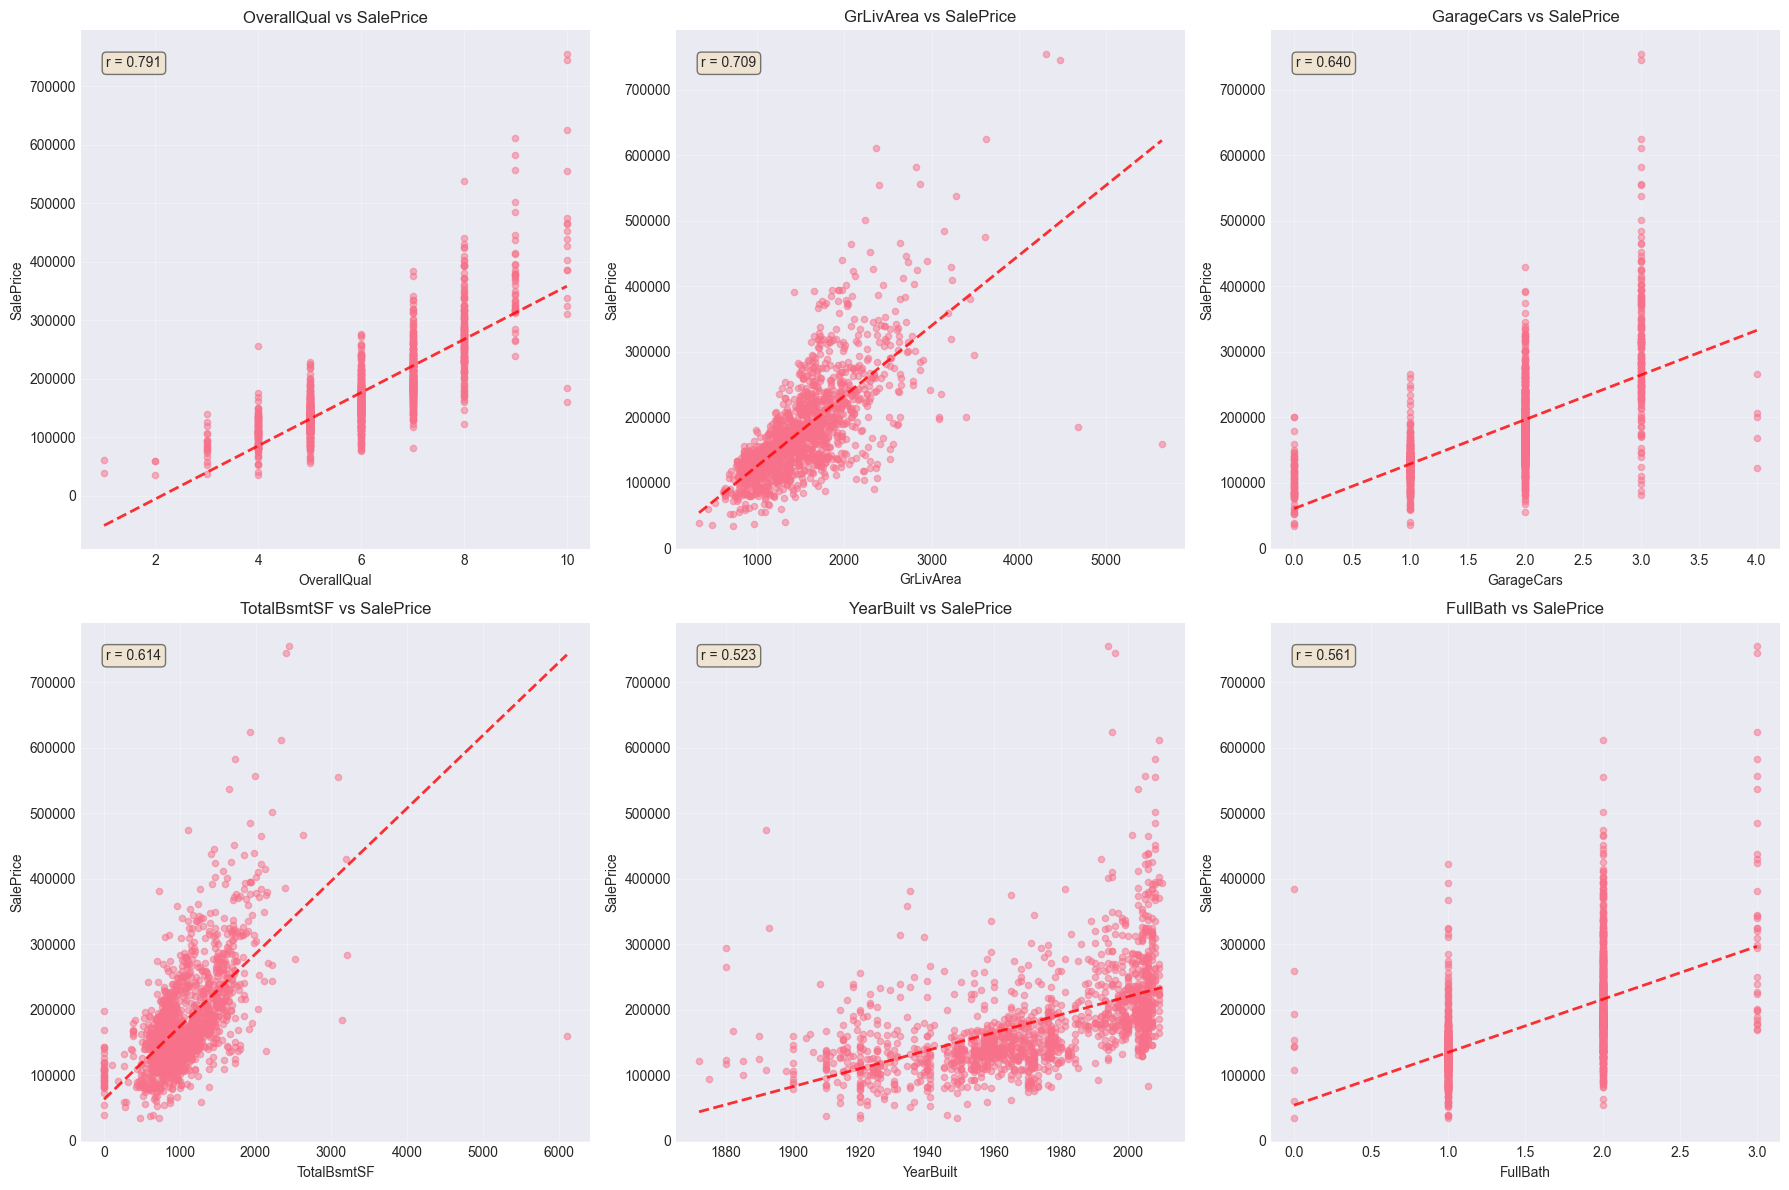

In [12]:
# Analyse des relations entre variables clés et prix
print("=" * 60)
print("RELATIONS VARIABLES CLÉS vs PRIX")
print("=" * 60)

# Variables à analyser
key_analysis_vars = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 
                     'YearBuilt', 'FullBath']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, var in enumerate(key_analysis_vars):
    if var in train_df.columns:
        if train_df[var].dtype in ['int64', 'float64']:
            # Scatter plot pour variables numériques
            axes[idx].scatter(train_df[var], train_df['SalePrice'], alpha=0.5, s=20)
            axes[idx].set_xlabel(var)
            axes[idx].set_ylabel('SalePrice')
            axes[idx].set_title(f'{var} vs SalePrice')
            
            # Ajouter une ligne de tendance
            z = np.polyfit(train_df[var].dropna(), train_df.loc[train_df[var].notna(), 'SalePrice'], 1)
            p = np.poly1d(z)
            x_line = np.linspace(train_df[var].min(), train_df[var].max(), 100)
            axes[idx].plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
            
            # Calculer la corrélation
            corr = train_df[[var, 'SalePrice']].corr().iloc[0, 1]
            axes[idx].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[idx].transAxes,
                          verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        else:
            # Box plot pour variables catégorielles
            categories = train_df[var].value_counts().head(10).index
            data_to_plot = [train_df[train_df[var] == cat]['SalePrice'].values for cat in categories]
            axes[idx].boxplot(data_to_plot, labels=categories)
            axes[idx].set_xlabel(var)
            axes[idx].set_ylabel('SalePrice')
            axes[idx].set_title(f'{var} vs SalePrice')
            axes[idx].tick_params(axis='x', rotation=45)
        
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/key_vars_vs_price.png', dpi=300, bbox_inches='tight')
plt.show()


## 11. Résumé et Conclusions

### Points Clés à Retenir:

1. **Structure du Dataset**:
   - 1460 observations d'entraînement
   - 80 variables explicatives + 1 variable cible (SalePrice)
   - Mix de variables numériques et catégorielles

2. **Variable Cible**:
   - Distribution asymétrique à droite
   - Nécessite une transformation logarithmique
   - Prix moyen: ~$180,000

3. **Variables les Plus Importantes**:
   - OverallQual (qualité globale)
   - GrLivArea (surface habitable)
   - GarageCars (taille du garage)
   - TotalBsmtSF (surface du sous-sol)

4. **Valeurs Manquantes**:
   - Plusieurs colonnes contiennent des valeurs manquantes
   - Nécessite un traitement approprié

5. **Outliers**:
   - Présence d'outliers dans certaines variables
   - Nécessite une analyse et un traitement

### Prochaines Étapes:

- Nettoyage des données
- Traitement des valeurs manquantes
- Feature engineering
- Modélisation


In [13]:
# Générer un rapport récapitulatif
print("=" * 60)
print("RAPPORT RÉCAPITULATIF")
print("=" * 60)

print("\nRESUME DU DATASET")
print(f"   Observations d'entrainement: {train_df.shape[0]:,}")
print(f"   Variables totales: {train_df.shape[1]}")
print(f"   Variables numeriques: {len(numeric_cols)}")
print(f"   Variables categorielles: {len(categorical_cols)}")

print("\nVARIABLE CIBLE (SalePrice)")
print(f"   Plage: ${train_df['SalePrice'].min():,.0f} - ${train_df['SalePrice'].max():,.0f}")
print(f"   Moyenne: ${train_df['SalePrice'].mean():,.0f}")
print(f"   Mediane: ${train_df['SalePrice'].median():,.0f}")
print(f"   Skewness: {train_df['SalePrice'].skew():.3f}")

print("\nVALEURS MANQUANTES")
missing_count = train_df.isnull().sum().sum()
missing_cols_count = (train_df.isnull().sum() > 0).sum()
print(f"   Total de valeurs manquantes: {missing_count:,}")
print(f"   Colonnes avec valeurs manquantes: {missing_cols_count}")

print("\nTOP 5 VARIABLES CORRELEES AVEC SALEPRICE")
top_5_corr = correlations.drop('SalePrice').head(5)
for var, corr in top_5_corr.items():
    print(f"   {var:20s}: {corr:.3f}")

print("\nExploration terminee!")
print("=" * 60)


RAPPORT RÉCAPITULATIF

RESUME DU DATASET
   Observations d'entrainement: 1,460
   Variables totales: 81
   Variables numeriques: 38
   Variables categorielles: 43

VARIABLE CIBLE (SalePrice)
   Plage: $34,900 - $755,000
   Moyenne: $180,921
   Mediane: $163,000
   Skewness: 1.883

VALEURS MANQUANTES
   Total de valeurs manquantes: 7,829
   Colonnes avec valeurs manquantes: 19

TOP 5 VARIABLES CORRELEES AVEC SALEPRICE
   OverallQual         : 0.791
   GrLivArea           : 0.709
   GarageCars          : 0.640
   GarageArea          : 0.623
   TotalBsmtSF         : 0.614

Exploration terminee!
